In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path().absolute().parent))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import glob
import re

---

In [2]:
# Define experiment name
EXPERIMENT_NAME = "group_based_transfer"

# Define paths to results
benchmark_results_dir = Path(f"/Users/cooper/Desktop/CAMELS-CH/experiments/GroupBased/results/{EXPERIMENT_NAME}_benchmark")
challenger_results_dir = Path(f"/Users/cooper/Desktop/CAMELS-CH/experiments/GroupBased/results/{EXPERIMENT_NAME}")

# Function to load basin metrics from benchmark
def load_benchmark_basin_metrics():
    """Load basin metrics from benchmark model runs"""
    basin_metrics_files = glob.glob(str(benchmark_results_dir / "benchmark_basin_metrics_*.csv"))
    
    all_metrics = []
    for file_path in basin_metrics_files:
        # Extract run number
        run_match = re.search(r"benchmark_basin_metrics_(\d+)\.csv", file_path)
        if run_match:
            run = int(run_match.group(1))
            metrics_df = pd.read_csv(file_path)
            metrics_df['run'] = run
            metrics_df['model'] = 'benchmark'
            all_metrics.append(metrics_df)
    
    if all_metrics:
        return pd.concat(all_metrics, ignore_index=True)
    else:
        print(f"No benchmark basin metrics found in {benchmark_results_dir}")
        return pd.DataFrame()

# Function to load basin metrics from challenger groups
def load_challenger_basin_metrics():
    """Load basin metrics from challenger group model runs"""
    group_dirs = [d for d in challenger_results_dir.iterdir() if d.is_dir()]
    
    all_metrics = []
    for group_dir in group_dirs:
        group_key = group_dir.name
        basin_metrics_files = glob.glob(str(group_dir / "basin_metrics_*.csv"))
        
        for file_path in basin_metrics_files:
            # Extract run number
            run_match = re.search(r"basin_metrics_(\d+)\.csv", file_path)
            if run_match:
                run = int(run_match.group(1))
                metrics_df = pd.read_csv(file_path)
                metrics_df['run'] = run
                metrics_df['model'] = f'challenger_{group_key}'
                metrics_df['group'] = group_key
                all_metrics.append(metrics_df)
    
    if all_metrics:
        return pd.concat(all_metrics, ignore_index=True)
    else:
        print(f"No challenger basin metrics found in {challenger_results_dir}")
        return pd.DataFrame()

# Load all metrics
benchmark_metrics = load_benchmark_basin_metrics()
challenger_metrics = load_challenger_basin_metrics()

# Display info about loaded data
print(f"Benchmark metrics shape: {benchmark_metrics.shape}")
print(f"Challenger metrics shape: {challenger_metrics.shape}")

# Check loaded data
if not benchmark_metrics.empty:
    print("\nBenchmark metrics sample:")
    print(benchmark_metrics.head(10))
    
if not challenger_metrics.empty:
    print("\nChallenger metrics sample:")
    print(challenger_metrics.head(10))
    
    # Show unique groups in challenger metrics
    print("\nUnique challenger groups:")
    print(challenger_metrics['group'].unique())

Benchmark metrics shape: (480, 8)
Challenger metrics shape: (6080, 9)

Benchmark metrics sample:
   basin_id  horizon       MSE       MAE       NSE      RMSE  run      model
0  CA_15013        1  0.138694  0.199070  0.936866  0.372416    0  benchmark
1  CA_15013        2  0.261017  0.268388  0.881171  0.510898    0  benchmark
2  CA_15013        3  0.358768  0.315820  0.836656  0.598972    0  benchmark
3  CA_15013        4  0.439611  0.344810  0.799827  0.663031    0  benchmark
4  CA_15013        5  0.504851  0.368986  0.770094  0.710528    0  benchmark
5  CA_15013        6  0.579626  0.394462  0.735994  0.761332    0  benchmark
6  CA_15013        7  0.621771  0.407246  0.716755  0.788525    0  benchmark
7  CA_15013        8  0.675046  0.425187  0.692433  0.821612    0  benchmark
8  CA_15013        9  0.683892  0.429075  0.688344  0.826977    0  benchmark
9  CA_15013       10  0.720035  0.440548  0.671816  0.848549    0  benchmark

Challenger metrics sample:
   basin_id  horizon       M

In [3]:
# Function to extract and clean basin_id from index
def extract_basin_id(index_value):
    if isinstance(index_value, tuple):
        # Handle MultiIndex: (basin_id, horizon)
        basin_id = index_value[0]
    else:
        # Handle string index
        basin_id = index_value
    
    # Return as string and ensure it's a valid basin ID
    basin_id_str = str(basin_id)
    return basin_id_str

# Extract basin IDs
def extract_and_prep_metrics(df):
    # Create a copy to avoid modifying the original
    result_df = df.copy()
    
    # Check if we're dealing with MultiIndex
    if isinstance(result_df.index, pd.MultiIndex):
        # Reset MultiIndex to get basin_id and horizon as columns
        result_df = result_df.reset_index()
    else:
        # Add basin_id column from index
        result_df['basin_id'] = result_df.index
        result_df = result_df.reset_index(drop=True)
    
    # Ensure basin_id is string
    result_df['basin_id'] = result_df['basin_id'].astype(str)
    
    # Filter for only CA basins
    result_df = result_df[result_df['basin_id'].str.startswith('CA_')]
    
    return result_df

# Process both datasets
benchmark_processed = extract_and_prep_metrics(benchmark_metrics)
challenger_processed = extract_and_prep_metrics(challenger_metrics)

# Find common CA basins
benchmark_basins = set(benchmark_processed['basin_id'])
challenger_basins = set(challenger_processed['basin_id'])
common_basins = benchmark_basins.intersection(challenger_basins)

print(f"Total benchmark CA basins: {len(benchmark_basins)}")
print(f"Total challenger CA basins: {len(challenger_basins)}")
print(f"Common CA basins: {len(common_basins)}")

# Filter both datasets to only include common basins
benchmark_common = benchmark_processed[benchmark_processed['basin_id'].isin(common_basins)]
challenger_common = challenger_processed[challenger_processed['basin_id'].isin(common_basins)]

# Show sample of aligned data
print("\nSample of benchmark data for common basins:")
print(benchmark_common.head())

print("\nSample of challenger data for common basins:")
print(challenger_common.head())

# Organize data by basin and horizon for easier comparison
def organize_by_basin_horizon(df):
    # If horizon is in the DataFrame columns
    if 'horizon' in df.columns:
        return df.set_index(['basin_id', 'horizon'])
    else:
        # If we're working with a MultiIndex already reset earlier
        print("Warning: 'horizon' column not found, using only basin_id as index")
        return df.set_index('basin_id')

benchmark_indexed = organize_by_basin_horizon(benchmark_common)
challenger_indexed = organize_by_basin_horizon(challenger_common)

print("\nIndexed benchmark data:")
print(benchmark_indexed.head())

print("\nIndexed challenger data:")
print(challenger_indexed.head())

# Count how many basins we have per group in the challenger data
if 'group' in challenger_common.columns:
    basins_per_group = challenger_common.groupby('group')['basin_id'].nunique()
    print("\nNumber of common CA basins per challenger group:")
    print(basins_per_group)

Total benchmark CA basins: 0
Total challenger CA basins: 0
Common CA basins: 0

Sample of benchmark data for common basins:
Empty DataFrame
Columns: [basin_id, horizon, MSE, MAE, NSE, RMSE, run, model]
Index: []

Sample of challenger data for common basins:
Empty DataFrame
Columns: [basin_id, horizon, MSE, MAE, NSE, RMSE, run, model, group]
Index: []

Indexed benchmark data:
Empty DataFrame
Columns: [MSE, MAE, NSE, RMSE, run, model]
Index: []

Indexed challenger data:
Empty DataFrame
Columns: [MSE, MAE, NSE, RMSE, run, model, group]
Index: []

Number of common CA basins per challenger group:
Series([], Name: basin_id, dtype: int64)


In [4]:
# Direct comparison of basin IDs
benchmark_basins = set(benchmark_metrics['basin_id'])
challenger_basins = set(challenger_metrics['basin_id'])
common_basins = benchmark_basins.intersection(challenger_basins)

print(f"Number of basins in benchmark: {len(benchmark_basins)}")
print(f"Number of basins in challengers: {len(challenger_basins)}")
print(f"Number of common basins: {len(common_basins)}")
print("Sample common basins:", list(common_basins)[:5] if common_basins else "None")

# Function to compare performance without preprocessing
def compare_all_performance(benchmark_df, challenger_df, horizons=[1, 5, 10], metrics=['NSE', 'RMSE']):
    """Compare performance between benchmark and challenger for all basins"""
    results = []
    
    # Get all unique basins
    all_basins = set(benchmark_df['basin_id']).intersection(challenger_df['basin_id'])
    
    for basin_id in all_basins:
        # Filter data for this basin
        benchmark_basin = benchmark_df[benchmark_df['basin_id'] == basin_id]
        
        # Get challenger data for this basin, could be from either group
        challenger_basin = challenger_df[challenger_df['basin_id'] == basin_id]
        
        # Get the group this basin belongs to
        group = challenger_basin['group'].iloc[0] if 'group' in challenger_basin else "Unknown"
        
        for horizon in horizons:
            benchmark_h = benchmark_basin[benchmark_basin['horizon'] == horizon]
            challenger_h = challenger_basin[challenger_basin['horizon'] == horizon]
            
            if benchmark_h.empty or challenger_h.empty:
                continue
                
            row = {
                'basin_id': basin_id,
                'horizon': horizon,
                'group': group
            }
            
            for metric in metrics:
                benchmark_val = benchmark_h[metric].values[0]
                challenger_val = challenger_h[metric].values[0]
                difference = challenger_val - benchmark_val
                
                row[f'benchmark_{metric}'] = benchmark_val
                row[f'challenger_{metric}'] = challenger_val
                row[f'diff_{metric}'] = difference
                
                # Add improvement flag (True if challenger is better)
                if metric == 'NSE':
                    # For NSE, higher is better
                    row[f'improved_{metric}'] = difference > 0
                else:
                    # For RMSE and MAE, lower is better
                    row[f'improved_{metric}'] = difference < 0
                    
            results.append(row)
    
    return pd.DataFrame(results)

# Compare performance for all basins
comparison_df = compare_all_performance(benchmark_metrics, challenger_metrics)

if not comparison_df.empty:
    # Summarize improvement by horizon
    horizon_summary = comparison_df.groupby('horizon').agg({
        'improved_NSE': 'mean',
        'improved_RMSE': 'mean',
        'diff_NSE': 'mean',
        'diff_RMSE': 'mean',
        'basin_id': 'count'
    }).rename(columns={'basin_id': 'count'})
    
    print("\nPerformance improvement by horizon (proportion of basins with improvement):")
    print(horizon_summary)
    
    # Summarize improvement by group
    if 'group' in comparison_df.columns:
        group_summary = comparison_df.groupby(['group', 'horizon']).agg({
            'improved_NSE': 'mean',
            'improved_RMSE': 'mean',
            'diff_NSE': 'mean',
            'diff_RMSE': 'mean',
            'basin_id': 'count'
        }).rename(columns={'basin_id': 'count'})
        
        print("\nPerformance improvement by group and horizon:")
        print(group_summary)
else:
    print("No common basins found for comparison")

Number of basins in benchmark: 48
Number of basins in challengers: 460
Number of common basins: 48
Sample common basins: ['CA_15034', 'CA_15045', 'CA_15259', 'CA_15283', 'CA_15044']

Performance improvement by horizon (proportion of basins with improvement):
         improved_NSE  improved_RMSE  diff_NSE  diff_RMSE  count
horizon                                                         
1            0.020833       0.020833 -0.082477   0.187778     48
5            0.104167       0.104167 -0.039743   0.070368     48
10           0.125000       0.125000 -0.030386   0.045460     48

Performance improvement by group and horizon:
                improved_NSE  improved_RMSE  diff_NSE  diff_RMSE  count
group  horizon                                                         
group1 1            0.000000       0.000000 -0.116512   0.267671     29
       5            0.034483       0.034483 -0.050204   0.093690     29
       10           0.137931       0.137931 -0.034153   0.054000     29
group2 1 

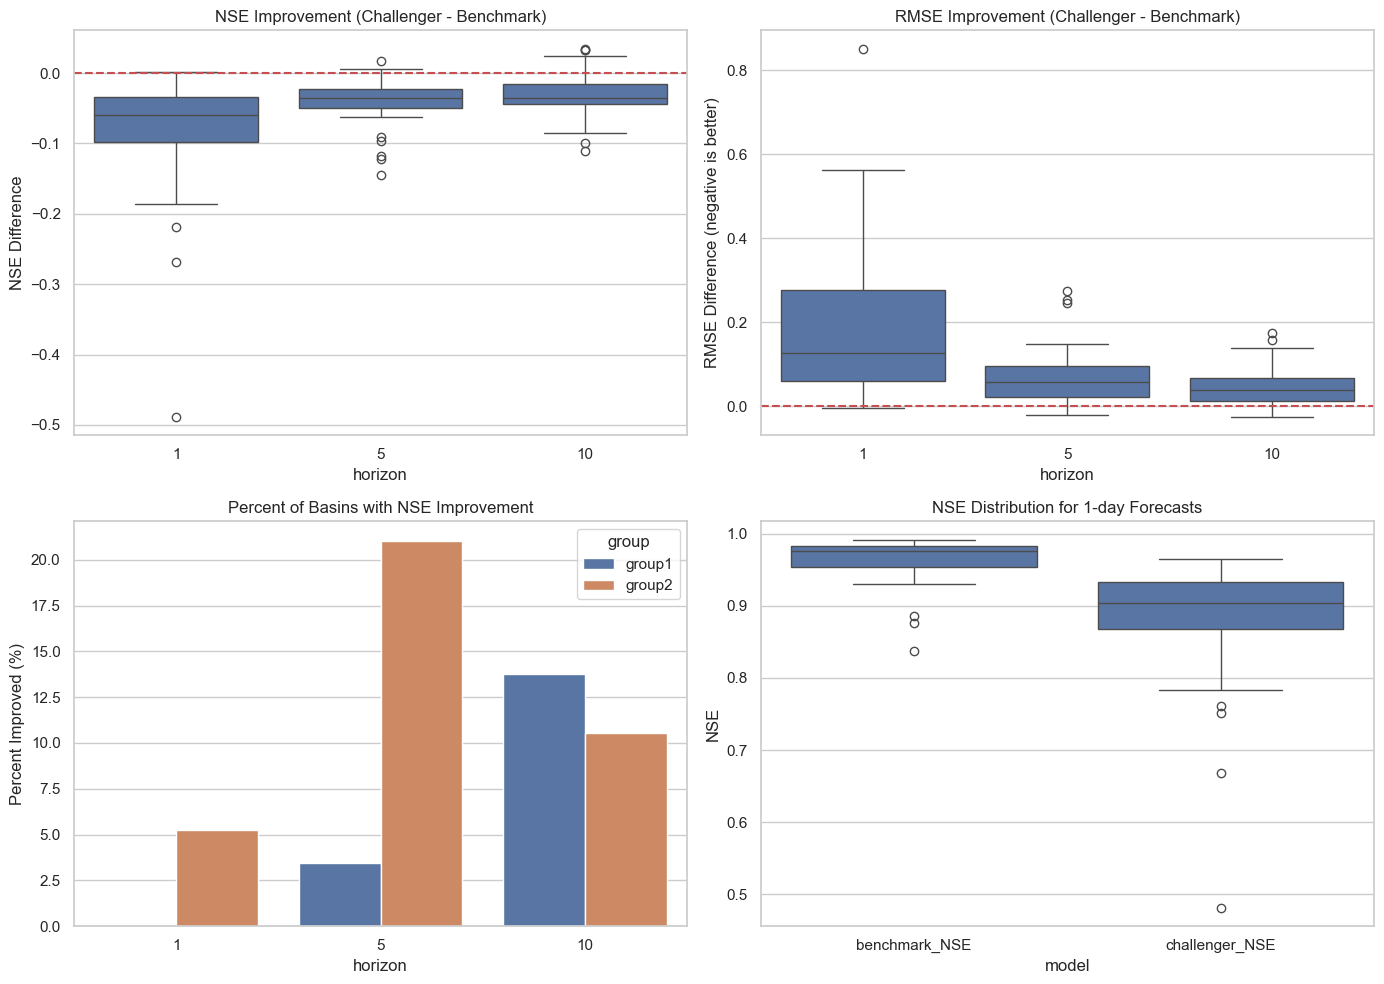


Number of basins with at least one improved horizon: 8

Analysis of basins with improvement:

Basin CA_15025 (Group: group1):
  Horizon 10: NSE improved by 0.0078 (Benchmark: 0.8836, Challenger: 0.8914)

Basin CA_16134 (Group: group2):
  Horizon 1: NSE improved by 0.0014 (Benchmark: 0.9359, Challenger: 0.9373)
  Horizon 5: NSE improved by 0.0018 (Benchmark: 0.8456, Challenger: 0.8474)

Basin CA_15090 (Group: group1):
  Horizon 10: NSE improved by 0.0064 (Benchmark: 0.6675, Challenger: 0.6738)

Basin CA_16143 (Group: group2):
  Horizon 5: NSE improved by 0.0025 (Benchmark: 0.8900, Challenger: 0.8924)

Basin CA_17137 (Group: group1):
  Horizon 5: NSE improved by 0.0166 (Benchmark: 0.7812, Challenger: 0.7978)
  Horizon 10: NSE improved by 0.0242 (Benchmark: 0.7139, Challenger: 0.7382)

Basin CA_17344 (Group: group2):
  Horizon 5: NSE improved by 0.0048 (Benchmark: 0.7244, Challenger: 0.7292)
  Horizon 10: NSE improved by 0.0322 (Benchmark: 0.5992, Challenger: 0.6314)

Basin CA_16153 (Gro

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set(style="whitegrid")
plt.figure(figsize=(14, 10))

# 1. Plot NSE improvement distribution by horizon
plt.subplot(2, 2, 1)
sns.boxplot(x='horizon', y='diff_NSE', data=comparison_df)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('NSE Improvement (Challenger - Benchmark)')
plt.ylabel('NSE Difference')

# 2. Plot RMSE improvement distribution by horizon
plt.subplot(2, 2, 2)
sns.boxplot(x='horizon', y='diff_RMSE', data=comparison_df)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('RMSE Improvement (Challenger - Benchmark)')
plt.ylabel('RMSE Difference (negative is better)')

# 3. Bar chart of improvement rate by group and horizon
group_horizon_counts = comparison_df.groupby(['group', 'horizon'])['improved_NSE'].mean()*100
group_horizon_df = group_horizon_counts.reset_index()

plt.subplot(2, 2, 3)
sns.barplot(x='horizon', y='improved_NSE', hue='group', data=group_horizon_df)
plt.title('Percent of Basins with NSE Improvement')
plt.ylabel('Percent Improved (%)')

# 4. Examine distribution of absolute performance
plt.subplot(2, 2, 4)
comparison_melted = pd.melt(
    comparison_df[comparison_df['horizon'] == 1],
    id_vars=['basin_id', 'group'],
    value_vars=['benchmark_NSE', 'challenger_NSE'],
    var_name='model', value_name='NSE'
)
sns.boxplot(x='model', y='NSE', data=comparison_melted)
plt.title('NSE Distribution for 1-day Forecasts')

plt.tight_layout()
plt.savefig('performance_comparison.png', dpi=300)
plt.show()

# Additional detailed analysis
# Compare performance for basins where challenger performs better
improved_basins = comparison_df[comparison_df['improved_NSE'] == True]['basin_id'].unique()
print(f"\nNumber of basins with at least one improved horizon: {len(improved_basins)}")

if len(improved_basins) > 0:
    # Look at those basins specifically
    improved_comparison = comparison_df[comparison_df['basin_id'].isin(improved_basins)]
    print("\nAnalysis of basins with improvement:")
    for basin in improved_basins:
        basin_data = improved_comparison[improved_comparison['basin_id'] == basin]
        print(f"\nBasin {basin} (Group: {basin_data['group'].iloc[0]}):")
        for _, row in basin_data.iterrows():
            if row['improved_NSE']:
                print(f"  Horizon {int(row['horizon'])}: NSE improved by {row['diff_NSE']:.4f} (Benchmark: {row['benchmark_NSE']:.4f}, Challenger: {row['challenger_NSE']:.4f})")